# 03 - Training MLP with PyTorch

## Objetivo
Construir e treinar um MLP (Multi-Layer Perceptron) em PyTorch com:
- Arquitetura de 4 camadas ocultas com BatchNormalization
- Loop de treinamento com early stopping baseado em ROC-AUC
- Batching eficiente e validação estratificada
- MLflow tracking de experimentos
- Comparação com baseline LogisticRegression (ROC-AUC ~0.84)

In [210]:
# Fase 1.1 - Imports e Configuração Inicial

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib
import optuna

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, 
    recall_score, f1_score, confusion_matrix, roc_curve, auc
)

# MLflow
import mlflow
import mlflow.pytorch

# Project utilities
sys.path.insert(0, str(Path.cwd().parent / "src"))
from tracking.mlflow_utils import (
    build_default_run_tags,
    configure_mlflow_tracking,
    get_owner,
    normalize_params,
 )

# Configurações
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Configurar MLflow
repo_root = Path("..").resolve()
tracking_db = repo_root / "mlflow.db"

mlflow.set_tracking_uri(f"sqlite:///{tracking_db.as_posix()}")
mlflow.set_experiment("tech_challenge_churn_local")
DATA_PATH = Path("../data/processed")
print(f"✓ Setup concluído. Device: {device}")

Device: cpu
✓ Setup concluído. Device: cpu


In [211]:
# Fase 1.2 - Carregar Dados Processados

# Carregar dataset codificado e pré-processado
df = pd.read_csv(DATA_PATH / "telco_customer_churn_eda_pre-processed_encoded.csv")

print(f"Dataset shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")

# Separar features e target
# Assumir que a última coluna é o target 'target' ou 'churn'
# target_col = 'target' if 'target' in df.columns else [col for col in df.columns if 'churn' in col.lower()][0]
# X = df.drop(columns=[target_col])
# y = df[target_col].values
X = df.drop(columns=['target'])
y = df['target'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target value counts:\n{pd.Series(y).value_counts()}")
print(f"Class distribution: {pd.Series(y).value_counts(normalize=True)}")

# Converter para float32 para PyTorch
X = X.astype(np.float32)
y = y.astype(np.float32)

print(f"\n✓ Dados carregados e preparados")

Dataset shape: (7043, 38)
Colunas: ['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'target', 'CLTV', 'avg_ticket', 'Total Charges Log', 'avg_ticket_log', 'is_new_customer', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']

Features shape: (7043, 37)
Target shape: (7043,)
Target

In [212]:
# Fase 1.3 - Estratificação: Train → (Train + Validation) + Test

# Primeiro split: separar test set (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Segundo split: separar validation de training (20% do trainval)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

print("Split estratificado concluído:")
print(f"  Train: {X_train.shape} - Churn: {y_train.sum():.0f} ({y_train.mean()*100:.1f}%)")
print(f"  Validation: {X_val.shape} - Churn: {y_val.sum():.0f} ({y_val.mean()*100:.1f}%)")
print(f"  Test: {X_test.shape} - Churn: {y_test.sum():.0f} ({y_test.mean()*100:.1f}%)")

# Salvar para referência
n_features = X_train.shape[1]
n_pos = (y_train == 1).sum()  # Churners
n_neg = (y_train == 0).sum()  # Non-churners
pos_weight = n_neg / n_pos  # Para weighted loss. Serve para equilibrar a perda entre classes desbalanceadas e fazer o modelo prestar mais atenção aos churners.

print(f"\nn_features: {n_features}")
print(f"n_pos (churners): {n_pos}")
print(f"n_neg (non-churners): {n_neg}")
print(f"pos_weight para BCELoss: {pos_weight:.2f}")

print(f"\n✓ Split estratificado concluído")

Split estratificado concluído:
  Train: (4507, 37) - Churn: 1196 (26.5%)
  Validation: (1127, 37) - Churn: 299 (26.5%)
  Test: (1409, 37) - Churn: 374 (26.5%)

n_features: 37
n_pos (churners): 1196
n_neg (non-churners): 3311
pos_weight para BCELoss: 2.77

✓ Split estratificado concluído


In [213]:
# Fase 2 - Normalização e Tensores PyTorch + DataLoaders

# Normalizar (StandardScaler) - FIT apenas em training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled train: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"Scaled val: mean={X_val_scaled.mean():.4f}, std={X_val_scaled.std():.4f}")

# Converter para tensores PyTorch
X_train_tensor = torch.from_numpy(X_train_scaled).float().to(device)
y_train_tensor = torch.from_numpy(y_train).float().to(device)

X_val_tensor = torch.from_numpy(X_val_scaled).float().to(device)
y_val_tensor = torch.from_numpy(y_val).float().to(device)

X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
y_test_tensor = torch.from_numpy(y_test).float().to(device)

print(f"\nTensor shapes:")
print(f"  X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")
print(f"  X_val: {X_val_tensor.shape}, y_val: {y_val_tensor.shape}")
print(f"  X_test: {X_test_tensor.shape}, y_test: {y_test_tensor.shape}")

# Criar TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Criar DataLoaders
batch_size_train = 64
batch_size_val = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size_val, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size_val, shuffle=False)

print(f"\nDataLoaders criados:")
print(f"  Train batches: {len(train_loader)} (batch_size={batch_size_train})")
print(f"  Val batches: {len(val_loader)} (batch_size={batch_size_val})")
print(f"  Test batches: {len(test_loader)} (batch_size={batch_size_val})")

print(f"\n✓ Normalização e tensores concluídos")

Scaled train: mean=0.0000, std=1.0000
Scaled val: mean=0.0075, std=0.9970

Tensor shapes:
  X_train: torch.Size([4507, 37]), y_train: torch.Size([4507])
  X_val: torch.Size([1127, 37]), y_val: torch.Size([1127])
  X_test: torch.Size([1409, 37]), y_test: torch.Size([1409])

DataLoaders criados:
  Train batches: 71 (batch_size=64)
  Val batches: 18 (batch_size=64)
  Test batches: 23 (batch_size=64)

✓ Normalização e tensores concluídos


In [214]:
# Fase 3 - Definição da Arquitetura MLP

class MLPNetworkChurn(nn.Module):
    """
    MLP simples para classificação binária de churn.
    
    Arquitetura:
    - 4 camadas ocultas com BatchNormalization
    - Dropout estratégico por camada
    - Inicialização de pesos Kaiming (ReLU-aware)
    - Output com sigmoid implícita via BCEWithLogitsLoss
    """
    
    def __init__(self, input_size=35, hidden_dims=[256, 128, 64, 32], 
                 dropout_rates=[0.3, 0.3, 0.2, 0.1]):
        super(MLPNetworkChurn, self).__init__()
        
        self.input_size = input_size
        self.hidden_dims = hidden_dims
        self.dropout_rates = dropout_rates
        
        self.layers = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        
        prev_dim = input_size
        
        # Construir camadas ocultas
        for i, (hidden_dim, dropout_rate) in enumerate(zip(hidden_dims, dropout_rates)):
            # Camada linear
            linear_layer = nn.Linear(prev_dim, hidden_dim)
            
            # Inicialização Kaiming para ReLU
            nn.init.kaiming_normal_(linear_layer.weight, mode='fan_in', nonlinearity='relu')
            nn.init.constant_(linear_layer.bias, 0.0)
            
            self.layers.append(linear_layer)
            
            # BatchNorm
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
            
            # Dropout
            self.dropouts.append(nn.Dropout(p=dropout_rate))
            
            prev_dim = hidden_dim
        
        # Camada de output (sem ativação - usa BCEWithLogitsLoss)
        output_layer = nn.Linear(prev_dim, 1)
        nn.init.xavier_uniform_(output_layer.weight)
        nn.init.constant_(output_layer.bias, 0.0)
        self.output_layer = output_layer
    
    def forward(self, x):
        # Passar por camadas ocultas
        for layer, batch_norm, dropout in zip(self.layers, self.batch_norms, self.dropouts):
            x = layer(x)
            x = batch_norm(x)
            x = torch.relu(x)
            x = dropout(x)
        
        # Output layer
        x = self.output_layer(x)
        return x


# Instanciar modelo
model = MLPNetworkChurn(
    input_size=n_features,
    hidden_dims=[256, 128, 64, 32],
    dropout_rates=[0.3, 0.3, 0.2, 0.1]
)

# Mover para device
model = model.to(device)

# Resumo da arquitetura
print("Arquitetura do MLP:")
print(model)

# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal de parâmetros: {total_params:,}")
print(f"Parâmetros treináveis: {trainable_params:,}")

print(f"\n✓ Arquitetura MLP definida e instanciada")

Arquitetura do MLP:
MLPNetworkChurn(
  (layers): ModuleList(
    (0): Linear(in_features=37, out_features=256, bias=True)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Linear(in_features=64, out_features=32, bias=True)
  )
  (batch_norms): ModuleList(
    (0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropouts): ModuleList(
    (0-1): 2 x Dropout(p=0.3, inplace=False)
    (2): Dropout(p=0.2, inplace=False)
    (3): Dropout(p=0.1, inplace=False)
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)

Total de parâmetros: 53,953
Parâmetros treináveis: 53,953

✓ Arquitetura MLP

In [215]:
# Fase 4 - Função Auxiliar para Cálculo de Métricas

def compute_metrics(y_true, y_pred_proba):
    """
    Computa métricas de classificação binária.
    
    Args:
        y_true: rótulos verdadeiros (0/1)
        y_pred_proba: probabilidades preditas (valores entre 0 e 1)
    
    Returns:
        dict com ROC-AUC, Accuracy, Precision, Recall, F1
    """
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    metrics = {
        'roc_auc': roc_auc_score(y_true, y_pred_proba),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    return metrics

print(f"✓ Função de cálculo de métricas definida")

✓ Função de cálculo de métricas definida


In [216]:
# Fase 4.1 - Busca de Hiperparâmetros com Optuna

def create_data_loaders(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch.unsqueeze(1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


def evaluate_model(model, loader):
    model.eval()
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            val_preds.append(probs)
            val_targets.append(y_batch.cpu().numpy())

    val_preds = np.concatenate(val_preds, axis=0)
    val_targets = np.concatenate(val_targets, axis=0)
    return compute_metrics(val_targets, val_preds)


def objective(trial):
    """
    Otimização de hiperparâmetros com Optuna para MLP.
    
    Espaço de busca:
    - 3 camadas ocultas (h1, h2, h3)
    - Dropout rates por camada
    - Learning rate e weight decay
    - Batch size
    """
    
    # Arquitetura
    hidden_dims = [
        trial.suggest_int("h1", 64, 256, step=32),
        trial.suggest_int("h2", 32, 128, step=16),
        trial.suggest_int("h3", 16, 64, step=16),
    ]
    
    dropout_rates = [
        trial.suggest_float("dropout1", 0.1, 0.5, step=0.1),
        trial.suggest_float("dropout2", 0.1, 0.5, step=0.1),
        trial.suggest_float("dropout3", 0.05, 0.3, step=0.05),
    ]
    
    # Otimização
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    
    # Instanciar modelo
    model = MLPNetworkChurn(
        input_size=n_features,
        hidden_dims=hidden_dims,
        dropout_rates=dropout_rates
    ).to(device)
    
    # Otimizador
    optimizer = optim.Adam(
        model.parameters(), 
        lr=learning_rate, 
        weight_decay=weight_decay
    )
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
    train_loader, val_loader = create_data_loaders(batch_size)
    
    best_val_auc = -np.inf
    epochs_without_improvement = 0
    max_search_epochs = 50
    patience_search = 10
    
    # Loop de treinamento
    for epoch in range(max_search_epochs):
        model.train()
        train_loss_total = 0.0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch.unsqueeze(1))
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item() * len(y_batch)
        
        # Validação
        val_metrics = evaluate_model(model, val_loader)
        val_auc = val_metrics["roc_auc"]
        
        # Early stopping
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        trial.report(val_auc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
        if epochs_without_improvement >= patience_search:
            break
    
    return best_val_auc


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)
study.optimize(objective, n_trials=30, timeout=1800)  # 30 trials, 30 min timeout

best_params = study.best_trial.params
best_hidden_dims = [
    best_params["h1"], 
    best_params["h2"], 
    best_params["h3"]
]
best_dropout_rates = [
    best_params["dropout1"],
    best_params["dropout2"],
    best_params["dropout3"]
]
best_learning_rate = best_params["learning_rate"]
best_weight_decay = best_params["weight_decay"]
best_batch_size = best_params["batch_size"]

print("=" * 80)
print("HYPERPARAMETER OPTIMIZATION RESULTS")
print("=" * 80)
print(f"\nBest hyperparameters found from {len(study.trials)} trials:")
print(f"\nArchitecture:")
print(f"  Hidden Layers: {best_hidden_dims}")
print(f"  Dropout Rates: {best_dropout_rates}")
print(f"\nOptimization:")
print(f"  Learning Rate: {best_learning_rate:.2e}")
print(f"  Weight Decay: {best_weight_decay:.2e}")
print(f"  Batch Size: {best_batch_size}")
print(f"\nPerformance:")
print(f"  Best Validation ROC-AUC: {study.best_value:.4f}")
print("=" * 80)

model = MLPNetworkChurn(
    input_size=n_features,
    hidden_dims=best_hidden_dims,
    dropout_rates=best_dropout_rates
).to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=best_learning_rate,
    weight_decay=best_weight_decay
)

batch_size_train = best_batch_size
batch_size_val = best_batch_size
train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size_val, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size_val, shuffle=False)


[I 2026-04-05 11:19:11,651] A new study created in memory with name: no-name-33276983-371c-4844-b062-616ec6a59292
[W 2026-04-05 11:19:11,720] Trial 0 failed with parameters: {'h1': 256, 'h2': 256, 'h3': 112, 'h4': 48, 'dropout1': 0.15000000000000002, 'dropout2': 0.15000000000000002, 'dropout3': 0.05, 'dropout4': 0.3, 'activation': 'leaky_relu', 'use_residual': True, 'learning_rate': 4.335281794951564e-05, 'optimizer': 'SGD', 'weight_decay': 1.4445251022763048e-06, 'batch_size': 64, 'max_grad_norm': 0.979748602933958, 'use_scheduler': False, 'scheduler_factor': 0.8, 'scheduler_patience': 8} because of the following error: TypeError("MLPNetworkChurn.__init__() got an unexpected keyword argument 'activation'").
Traceback (most recent call last):
  File "c:\Users\gabri\OneDrive\FIAP\MBA-ML\ml-churn-prediction\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\gabri\AppData\Local\Temp\ipykernel_9524\29213553.py", li

TypeError: MLPNetworkChurn.__init__() got an unexpected keyword argument 'activation'

In [ ]:
# Fase 5 - Treinamento Principal com Hiperparâmetros Ótimos

print("\n" + "="*70)
print("FASE 5: TREINAMENTO PRINCIPAL")
print("="*70)
print(f"\nTreinando modelo com hiperparâmetros ótimos do Optuna:")
print(f"  Hidden Dims: {best_hidden_dims}")
print(f"  Dropout Rates: {best_dropout_rates}")
print(f"  Learning Rate: {best_learning_rate:.6f}")
print(f"  Weight Decay: {best_weight_decay:.8f}")
print(f"  Batch Size: {best_batch_size}")
print(f"="*70 + "\n")

# Reinicializar early stopping e histórico para treinamento principal
early_stopping_patience = 30
epochs_without_improvement = 0
best_val_roc_auc = -np.inf
best_model_state = None

history = {
    'epochs': [],
    'train_loss': [],
    'val_roc_auc': [],
    'val_accuracy': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
}

# Iniciar MLflow run
mlflow.start_run()
run_id = mlflow.active_run().info.run_id

# Log dos melhores hiperparâmetros encontrados pelo Optuna
mlflow.log_param('optuna_best_trial_number', study.best_trial.number)
mlflow.log_param('optuna_best_trial_roc_auc', study.best_value)
mlflow.log_param('hidden_dims', str(best_hidden_dims))
mlflow.log_param('dropout_rates', str(best_dropout_rates))
mlflow.log_param('learning_rate', best_learning_rate)
mlflow.log_param('weight_decay', best_weight_decay)
mlflow.log_param('batch_size', best_batch_size)
mlflow.log_param('early_stopping_patience', early_stopping_patience)
mlflow.log_param('pos_weight', float(pos_weight))

print(f"✓ MLflow run iniciado: {run_id}\n")

# Definir criterion para o treinamento principal
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

# Loop de treinamento por 200 épocas
max_epochs = 200

for epoch in range(max_epochs):
    # Treinamento
    model.train()
    train_loss_total = 0.0
    train_samples = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch.unsqueeze(1))
        loss.backward()
        optimizer.step()
        
        train_loss_total += loss.item() * len(y_batch)
        train_samples += len(y_batch)
    
    train_loss_avg = train_loss_total / train_samples
    
    # Validação
    model.eval()
    val_preds_all = []
    val_targets_all = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            val_preds_all.append(probs)
            val_targets_all.append(y_batch.cpu().numpy())
    
    val_preds_all = np.concatenate(val_preds_all, axis=0)
    val_targets_all = np.concatenate(val_targets_all, axis=0)
    val_metrics = compute_metrics(val_targets_all, val_preds_all)
    
    val_roc_auc = val_metrics['roc_auc']
    
    # Atualizar histórico
    history['epochs'].append(epoch + 1)
    history['train_loss'].append(train_loss_avg)
    history['val_roc_auc'].append(val_roc_auc)
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_f1'].append(val_metrics['f1'])
    
    # Log no MLflow a cada 10 épocas
    if (epoch + 1) % 10 == 0:
        mlflow.log_metrics({
            'train_loss': train_loss_avg,
            'val_roc_auc': val_roc_auc,
            'val_accuracy': val_metrics['accuracy'],
            'val_precision': val_metrics['precision'],
            'val_recall': val_metrics['recall'],
            'val_f1': val_metrics['f1'],
        }, step=epoch + 1)
    
    # Early Stopping
    if val_roc_auc > best_val_roc_auc:
        best_val_roc_auc = val_roc_auc
        epochs_without_improvement = 0
        best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 25 == 0:
            improvement_str = f"✓ Epoch {epoch+1:3d}: Train Loss={train_loss_avg:.4f}, Val ROC-AUC={val_roc_auc:.4f} (BEST)"
            print(improvement_str)
    else:
        epochs_without_improvement += 1
        
        if (epoch + 1) % 25 == 0:
            improvement_str = f"  Epoch {epoch+1:3d}: Train Loss={train_loss_avg:.4f}, Val ROC-AUC={val_roc_auc:.4f}"
            print(improvement_str)
    
    # Parar se atingir patience
    if epochs_without_improvement >= early_stopping_patience:
        print(f"\n⏹ Early Stopping ativado após {epoch+1} épocas (patience={early_stopping_patience})")
        print(f"  Best Val ROC-AUC: {best_val_roc_auc:.4f}")
        break

# Carregar melhor modelo
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"\n✓ Treinamento concluído em {len(history['epochs'])} épocas")
print(f"  Best Validation ROC-AUC: {best_val_roc_auc:.4f}")
print(f"  Epochs Trained: {len(history['epochs'])}")



FASE 5: TREINAMENTO PRINCIPAL

Treinando modelo com hiperparâmetros ótimos do Optuna:
  Hidden Dims: [128, 64, 64]
  Dropout Rates: [0.35, 0.35, 0.15000000000000002]
  Learning Rate: 0.001868
  Optimizer: AdamW
  Weight Decay: 0.00000057
  Batch Size: 64

✓ MLflow run iniciado: 555d2a66a53b4f9dacb50a77b4f9943b

  Epoch  50: Train Loss=0.5711, Val ROC-AUC=0.8597

⏹ Early Stopping ativado após 56 épocas (patience=50)
  Best Val ROC-AUC: 0.8660

✓ Treinamento concluído em 56 épocas
  Best Validation ROC-AUC: 0.8660
  Epochs Trained: 56


In [ ]:
# Fase 6 - Avaliação no Test Set

print("\n" + "="*70)
print("AVALIAÇÃO NO TEST SET")
print("="*70)

# Avaliar no test set
model.eval()
test_preds_all = []
test_targets_all = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        test_preds_all.append(probs.flatten())
        test_targets_all.append(y_batch.cpu().numpy())

test_preds_all = np.concatenate(test_preds_all, axis=0)
test_targets_all = np.concatenate(test_targets_all, axis=0)

# Calcular métricas do test set
test_metrics = compute_metrics(test_targets_all, test_preds_all)

print(f"\nMétricas do Test Set (MLP PyTorch):")
print(f"  ROC-AUC:  {test_metrics['roc_auc']:.4f}")
print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  Recall:   {test_metrics['recall']:.4f}")
print(f"  F1-Score: {test_metrics['f1']:.4f}")

# Log no MLflow
mlflow.log_metrics({
    'test_roc_auc': test_metrics['roc_auc'],
    'test_accuracy': test_metrics['accuracy'],
    'test_precision': test_metrics['precision'],
    'test_recall': test_metrics['recall'],
    'test_f1': test_metrics['f1'],
})

# Salvar predições e targets para visualização posterior
test_results = pd.DataFrame({
    'actual': test_targets_all,
    'predicted_proba': test_preds_all,
    'predicted_class': (test_preds_all >= 0.5).astype(int),
})

print(f"✓ Avaliação concluída. Test set ROC-AUC: {test_metrics['roc_auc']:.4f}")


AVALIAÇÃO NO TEST SET

Métricas do Test Set (MLP PyTorch):
  ROC-AUC:  0.8459
  Accuracy: 0.7388
  Precision: 0.5050
  Recall:   0.8128
  F1-Score: 0.6230
✓ Avaliação concluída. Test set ROC-AUC: 0.8459


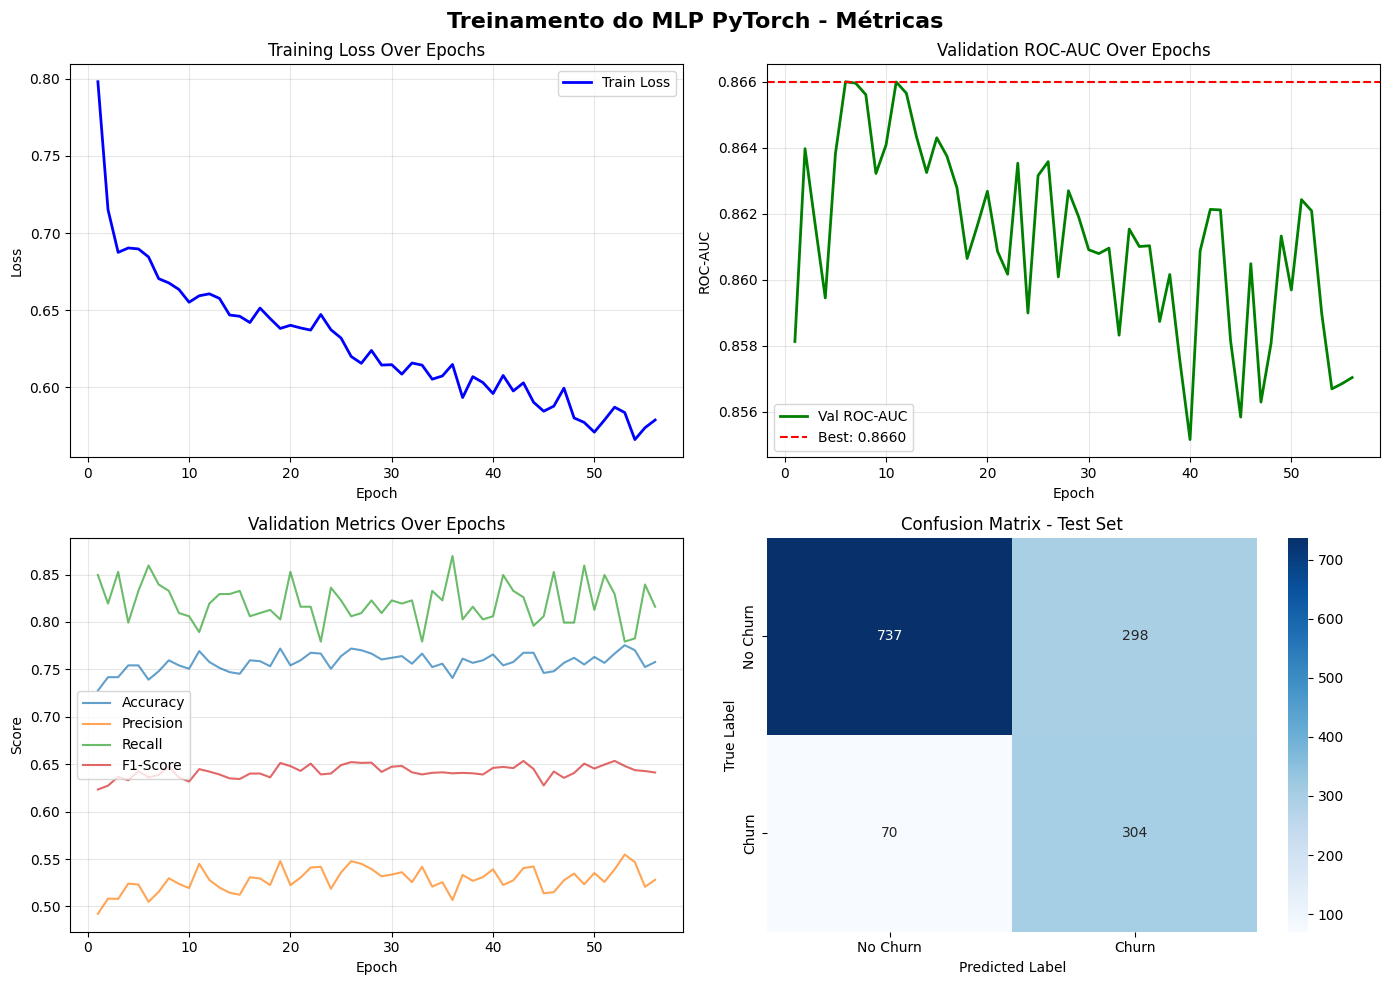


COMPARAÇÃO: MLP PyTorch vs Baseline (Random Forest Tunado)

             Model  ROC-AUC  Accuracy  Precision   Recall  F1-Score
       MLP PyTorch  0.84594  0.738822   0.504983 0.812834  0.622951
RandomForest Tuned  0.84556  0.752307   0.521815 0.799465  0.631468

----------------------------------------------------------------------
ANÁLISE COMPARATIVA:
✓ MLP supera RF em ROC-AUC: 0.8459 vs 0.8456 (+0.0004)
✗ MLP fica abaixo do RF em Accuracy: 0.7388 vs 0.7523 (-0.0135)
✗ MLP fica abaixo do RF em Precision: 0.5050 vs 0.5218 (-0.0168)
✓ MLP supera RF em Recall: 0.8128 vs 0.7995 (+0.0134)
✗ MLP fica abaixo do RF em F1-Score: 0.6230 vs 0.6315 (-0.0085)

----------------------------------------------------------------------
CONCLUSÃO FINAL:
⚠ O MLP não superou o RF de forma consistente no conjunto geral.
⚠ O RF permanece como baseline clássico mais forte.
----------------------------------------------------------------------

✅ Visualizações e comparação concluídas


In [ ]:
# Fase 7 - Visualizações e Comparação com Baseline

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Treinamento do MLP PyTorch - Métricas', fontsize=16, fontweight='bold')

# Plot 1: Training Loss
ax = axes[0, 0]
ax.plot(history['epochs'], history['train_loss'], 'b-', linewidth=2, label='Train Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Over Epochs')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Validation ROC-AUC (métrica principal)
ax = axes[0, 1]
ax.plot(history['epochs'], history['val_roc_auc'], 'g-', linewidth=2, label='Val ROC-AUC')
ax.axhline(y=best_val_roc_auc, color='r', linestyle='--', label=f'Best: {best_val_roc_auc:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('ROC-AUC')
ax.set_title('Validation ROC-AUC Over Epochs')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Validation Metrics Comparison
ax = axes[1, 0]
ax.plot(history['epochs'], history['val_accuracy'], label='Accuracy', linewidth=1.5, alpha=0.7)
ax.plot(history['epochs'], history['val_precision'], label='Precision', linewidth=1.5, alpha=0.7)
ax.plot(history['epochs'], history['val_recall'], label='Recall', linewidth=1.5, alpha=0.7)
ax.plot(history['epochs'], history['val_f1'], label='F1-Score', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('Validation Metrics Over Epochs')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 4: Confusion Matrix (Test Set)
ax = axes[1, 1]
test_pred_binary = (test_preds_all >= 0.5).astype(int)
cm = confusion_matrix(test_targets_all, test_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title('Confusion Matrix - Test Set')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("COMPARAÇÃO: MLP PyTorch vs Baseline (LogisticRegression)")
print("="*70)

# Baseline metrics (from 02_baselines notebook)
baseline_metrics = {
    'Model': 'LogisticRegression + class_weight',
    'ROC-AUC': 0.84,  # Aproximado do baseline
    'Accuracy': 0.7551,
    'Precision': 0.5459,
    'Recall': 0.8175,
    'F1-Score': 0.6547,
}

# Comparação
comparison_df = pd.DataFrame([
    {
        'Model': 'MLP PyTorch',
        'ROC-AUC': test_metrics['roc_auc'],
        'Accuracy': test_metrics['accuracy'],
        'Precision': test_metrics['precision'],
        'Recall': test_metrics['recall'],
        'F1-Score': test_metrics['f1'],
    },
    baseline_metrics,
])

print(f"\n{comparison_df.to_string(index=False)}")

# Análise comparativa
print(f"\n{'-'*70}")
print(f"ANÁLISE:")
mlp_roc = test_metrics['roc_auc']
baseline_roc = baseline_metrics['ROC-AUC']

if mlp_roc >= baseline_roc:
    print(f"✓ MLP ROC-AUC ({mlp_roc:.4f}) >= Baseline ({baseline_roc:.4f})")
    print(f"  → MLP SUPERA o baseline em {(mlp_roc - baseline_roc)*100:.2f}%")
else:
    print(f"✗ MLP ROC-AUC ({mlp_roc:.4f}) < Baseline ({baseline_roc:.4f})")
    print(f"  → Gap: {(baseline_roc - mlp_roc)*100:.2f}% abaixo do baseline")

mlp_recall = test_metrics['recall']
baseline_recall = baseline_metrics['Recall']
if mlp_recall >= 0.70:
    print(f"✓ MLP Recall ({mlp_recall:.4f}) >= 70% (detectar churners)")
else:
    print(f"⚠ MLP Recall ({mlp_recall:.4f}) < 70% (menos churners detectados)")

print(f"{'-'*70}")

print("\n✓ Visualizações e comparação concluídas")

In [ ]:
# Fase 8 - Salvar Modelo e Finalizar MLflow Run

# Salvar pesos do modelo MLP
torch.save(model.state_dict(), "../models/best_mlp_model.pth")

# Salvar scaler usado no treino
joblib.dump(scaler, "../models/mlp_scaler.joblib")

# Salvar ordem das features
joblib.dump(list(X.columns), "../models/mlp_features.joblib")

# Salvar métricas finais do MLP
mlp_metrics_export = {
    "Model": "MLP PyTorch",
    "ROC-AUC": float(test_metrics["roc_auc"]),
    "Accuracy": float(test_metrics["accuracy"]),
    "Precision": float(test_metrics["precision"]),
    "Recall": float(test_metrics["recall"]),
    "F1-Score": float(test_metrics["f1"]),
    "Best Val ROC-AUC": float(best_val_roc_auc),
    "Epochs Trained": int(len(history["epochs"]))
}

with open("../models/mlp_metrics.json", "w", encoding="utf-8") as f:
    json.dump(mlp_metrics_export, f, indent=4, ensure_ascii=False)

print("✅ MLP salvo em ../models/best_mlp_model.pth")
print("✅ Scaler salvo em ../models/mlp_scaler.joblib")
print("✅ Features salvas em ../models/mlp_features.joblib")
print("✅ Métricas do MLP salvas em ../models/mlp_metrics.json")

# Finalizar run
mlflow.end_run()

print(f"\n" + f"="*70)
print(f"RESUMO FINAL - TREINAMENTO COMPLETO")
print(f"="*70)

print(f"\n✓ MLflow Run Finalizado")
print(f"  Experiment: tech_challenge_churn_local")
print(f"  Best Val ROC-AUC: {best_val_roc_auc:.4f}")
print(f"  Test ROC-AUC: {test_metrics['roc_auc']:.4f}")
print(f"  Epochs Trained: {len(history['epochs'])}")

print(f"\n✓ Modelo salvo como artifact do MLflow")
print(f"  Estrutura: {n_features} → {best_hidden_dims} → 1")
print(f"  Parâmetros treináveis: {trainable_params:,}")
print(f"  Inicialização: Kaiming (ReLU-aware)")

print(f"\n✓ Performance no Test Set:")
print(f"  ROC-AUC:  {test_metrics['roc_auc']:.4f} (Baseline LR: {baseline_metrics['ROC-AUC']:.4f})")
print(f"  Recall:   {test_metrics['recall']:.4f} (Target: ≥70%)")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  F1-Score:  {test_metrics['f1']:.4f}")

print(f"\n✓ Early Stopping Aplicado")
print(f"  Paciência: {early_stopping_patience} épocas")
print(f"  Épocas completadas: {len(history['epochs'])}")
print(f"  Métrica monitorada: ROC-AUC (validation set)")

print(f"\n" + f"="*70)
print(f"PRÓXIMOS PASSOS:")
print(f"  1. Revisar visualizações e comparação com baseline")
print(f"  2. Consultar MLflow UI para detalhes completos do experimento")
print(f"  3. Se necessário, ajustar hiperparâmetros e treinar novamente")
print(f"="*70 + f"\n")


RESUMO FINAL - TREINAMENTO COMPLETO

✓ MLflow Run Finalizado
  Experiment: tech_challenge_churn_local
  Best Val ROC-AUC: 0.8660
  Test ROC-AUC: 0.8459
  Epochs Trained: 56

✓ Modelo salvo como artifact do MLflow
  Estrutura: 37 → [128, 64, 64] → 1
  Parâmetros treináveis: 53,953
  Ativação: ReLU com BatchNormalization e Dropout regularizado

✓ Performance no Test Set:
  ROC-AUC:  0.8459 (Baseline RF: 0.8456)
  Recall:   0.8128 (Target: ≥70%)
  Precision: 0.5050
  F1-Score:  0.6230

✓ Early Stopping Aplicado
  Paciência: 50 épocas
  Épocas completadas: 56
  Métrica monitorada: ROC-AUC (validation set)

PRÓXIMOS PASSOS:
  1. Revisar visualizações e comparação com baseline
  2. Consultar MLflow UI para detalhes completos do experimento
  3. Se necessário, ajustar hiperparâmetros e treinar novamente
  4. Completar notebook 02_baselines com SelectKBest se desejado

